In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import random


In [3]:
df = pd.read_csv("forecasting-dataset.csv")


In [4]:
df


,postcode,Day_of_Week,Date,Branch Name,Total Sale,outercode,population,households,avg_household_income,unemployment_rate,...,is_covid_lockdown,Inferred_Brand,Days_Since_Open,rateable_value,distance_to_nearest_station_mi,distance_to_mcdonalds_kfc_mi,distance_to_mosque_mi,distance_to_university_mi,workplace_to_resident_ratio,ethnic_diversity_index
0,KA21 5DT,Saturday,2/1/2025,galos peri peri hamilton,347.53,KA21,686,548,13716.9812,0.430,...,0,Galos,0,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.0160
1,KA21 5DT,Sunday,2/2/2025,galos peri peri hamilton,119.68,KA21,686,548,13716.9812,0.430,...,0,Galos,1,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.0160
2,KA21 5DT,Monday,2/3/2025,galos peri peri hamilton,136.20,KA21,686,548,13716.9812,0.430,...,0,Galos,2,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.0160
3,KA21 5DT,Tuesday,2/4/2025,galos peri peri hamilton,92.67,KA21,686,548,13716.9812,0.430,...,0,Galos,3,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.0160
4,KA21 5DT,Wednesday,2/5/2025,galos peri peri hamilton,124.94,KA21,686,548,13716.9812,0.430,...,0,Galos,4,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.0160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69348,WV1 1TQ,Thursday,6/26/2025,rio's piri piri wolverhampton,794.19,WV1,345,168,36481.0000,0.086,...,0,Rio's,832,8354.0,0.201000,0.052655,0.729161,0.172899,0.915,0.6348
69349,WV1 1TQ,Friday,6/27/2025,rio's piri piri wolverhampton,582.61,WV1,345,168,36481.0000,0.086,...,0,Rio's,833,8354.0,0.201000,0.052655,0.729161,0.172899,0.915,0.6348
69350,WV1 1TQ,Saturday,6/28/2025,rio's piri piri wolverhampton,458.56,WV1,345,168,36481.0000,0.086,...,0,Rio's,834,8354.0,0.201000,0.052655,0.729161,0.172899,0.915,0.6348
69351,WV1 1TQ,Sunday,6/29/2025,rio's piri piri wolverhampton,174.68,WV1,345,168,36481.0000,0.086,...,0,Rio's,835,8354.0,0.201000,0.052655,0.729161,0.172899,0.915,0.6348


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 69353 entries, 0 to 69352
Data columns (total 48 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   postcode                        69353 non-null  str    
 1   Day_of_Week                     69353 non-null  str    
 2   Date                            69353 non-null  str    
 3   Branch Name                     69353 non-null  str    
 4   Total Sale                      67699 non-null  float64
 5   outercode                       69353 non-null  str    
 6   population                      69353 non-null  int64  
 7   households                      69353 non-null  int64  
 8   avg_household_income            69353 non-null  float64
 9   unemployment_rate               69353 non-null  float64
 10  working                         69353 non-null  float64
 11  unemployed                      69353 non-null  float64
 12  ab                              69353 non-n

## 3. Data Cleaning

In [6]:
df.isnull().sum()


postcode                              0
Day_of_Week                           0
Date                                  0
Branch Name                           0
Total Sale                         1654
outercode                             0
population                            0
households                            0
avg_household_income                  0
unemployment_rate                     0
working                               0
unemployed                            0
ab                                    0
c1/c2                                 0
de                                    0
white                                 0
non-white                             0
Distance_to_Nearest_Station           0
Nearby_Station_Count                  0
Nearest_Station_Type                  0
Transport_Accessibility_Score         0
Dataset                               0
Brand Name                        69353
is_data_reliable                      0
Total_Sale_Normalized              1654


In [7]:
df =df.drop('Brand Name',axis=1)


In [8]:
df["Dataset"].unique()


<StringArray>
['Historical']
Length: 1, dtype: str

In [9]:
# from sklearn.impute import SimpleImputer

# s1=SimpleImputer(strategy='mean')

# df['Total Sale'] = s1.fit_transform(df[['Total Sale']])


In [10]:
df.isnull().sum()


postcode                             0
Day_of_Week                          0
Date                                 0
Branch Name                          0
Total Sale                        1654
outercode                            0
population                           0
households                           0
avg_household_income                 0
unemployment_rate                    0
working                              0
unemployed                           0
ab                                   0
c1/c2                                0
de                                   0
white                                0
non-white                            0
Distance_to_Nearest_Station          0
Nearby_Station_Count                 0
Nearest_Station_Type                 0
Transport_Accessibility_Score        0
Dataset                              0
is_data_reliable                     0
Total_Sale_Normalized             1654
is_logistics_strike                  0
is_delivery_crackdown    

In [11]:
df.shape


(69353, 47)

In [12]:
df = df.drop_duplicates()


In [13]:
df = df.drop(columns=["Total_Sale_Normalized"])


In [14]:
df = df.dropna(subset=["Total Sale"])


In [15]:
df["is_data_reliable"].value_counts()


is_data_reliable
1    66051
0     1648
Name: count, dtype: int64

In [16]:
print(df[["Distance_to_Nearest_Station", "distance_to_nearest_station_mi"]].corr())
print(df[["Distance_to_Nearest_Station", "distance_to_nearest_station_mi"]].head(10))


                                Distance_to_Nearest_Station  \
Distance_to_Nearest_Station                             1.0   
distance_to_nearest_station_mi                          1.0   

                                distance_to_nearest_station_mi  
Distance_to_Nearest_Station                                1.0  
distance_to_nearest_station_mi                             1.0  
   Distance_to_Nearest_Station  distance_to_nearest_station_mi
0                     0.241441                        0.241441
1                     0.241441                        0.241441
2                     0.241441                        0.241441
3                     0.241441                        0.241441
4                     0.241441                        0.241441
5                     0.241441                        0.241441
6                     0.241441                        0.241441
7                     0.241441                        0.241441
8                     0.241441                  

In [17]:
df = df.drop(columns=["Distance_to_Nearest_Station"])


In [18]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year
df = df.drop(columns=["Date"]) 


In [19]:
target_col = "Total Sale"

# Drop entirely — identifiers or already-encoded elsewhere
drop_cols = [
    "Dataset",
    "is_data_reliable",
]  # add postcode/outercode here too if high-cardinality and not useful

# Binary flags — already 0/1, no encoding needed
binary_flags = [
    "is_logistics_strike",
    "is_delivery_crackdown",
    "is_payday_window",
    "is_NYE",
    "is_NYD",
    "is_Christmas",
    "is_weekend",
    "is_month_start",
    "is_ramadan",
    "is_eid_al_fitr",
    "is_eid_al_adha",
    "is_Boxing_Day",
    "is_covid_lockdown",
]

# Categorical — need encoding
cat_cols = ["Day_of_Week", "Branch Name", "Nearest_Station_Type", "Inferred_Brand"]

# Numeric continuous — need scaling
num_cols = [
    "population",
    "households",
    "avg_household_income",
    "unemployment_rate",
    "working",
    "unemployed",
    "ab",
    "c1/c2",
    "de",
    "white",
    "non-white",
    "Distance_to_Nearest_Station",
    "Nearby_Station_Count",
    "Transport_Accessibility_Score",
    "Days_Since_Open",
    "rateable_value",
    "distance_to_mcdonalds_kfc_mi",
    "distance_to_mosque_mi",
    "distance_to_university_mi",
    "workplace_to_resident_ratio",
    "ethnic_diversity_index",
    "percent_muslim",
]

df = df.drop(columns=drop_cols)


In [20]:
# Drop postcode (high cardinality, redundant with outercode)
df = df.drop(columns=["postcode"])

# Add outercode to categorical columns (few-ish unique values expected, one-hot friendly)
cat_cols = [
    "Day_of_Week",
    "Branch Name",
    "Nearest_Station_Type",
    "Inferred_Brand",
    "outercode",
]


In [21]:
print(df["outercode"].nunique())


65


In [22]:
freq_map = df["outercode"].value_counts(normalize=True)
df["outercode_freq"] = df["outercode"].map(freq_map)
df = df.drop(columns=["outercode"])


In [23]:
X = df.drop(columns=[target_col])
y = df[target_col]

print(X.shape, y.shape)


(67699, 42) (67699,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [25]:
# Keep only columns that actually still exist in X_train
num_cols = [col for col in num_cols if col in X_train.columns]
cat_cols = [col for col in cat_cols if col in X_train.columns]
binary_flags = [col for col in binary_flags if col in X_train.columns]

print("num_cols:", num_cols)
print("cat_cols:", cat_cols)
print("binary_flags:", binary_flags)


num_cols: ['population', 'households', 'avg_household_income', 'unemployment_rate', 'working', 'unemployed', 'ab', 'c1/c2', 'de', 'white', 'non-white', 'Nearby_Station_Count', 'Transport_Accessibility_Score', 'Days_Since_Open', 'rateable_value', 'distance_to_mcdonalds_kfc_mi', 'distance_to_mosque_mi', 'distance_to_university_mi', 'workplace_to_resident_ratio', 'ethnic_diversity_index', 'percent_muslim']
cat_cols: ['Day_of_Week', 'Branch Name', 'Nearest_Station_Type', 'Inferred_Brand']
binary_flags: ['is_logistics_strike', 'is_delivery_crackdown', 'is_payday_window', 'is_NYE', 'is_NYD', 'is_Christmas', 'is_weekend', 'is_month_start', 'is_ramadan', 'is_eid_al_fitr', 'is_eid_al_adha', 'is_Boxing_Day', 'is_covid_lockdown']


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("bin", "passthrough", binary_flags),
    ]
)


In [27]:
print(df.isnull().sum())


Day_of_Week                       0
Branch Name                       0
Total Sale                        0
population                        0
households                        0
avg_household_income              0
unemployment_rate                 0
working                           0
unemployed                        0
ab                                0
c1/c2                             0
de                                0
white                             0
non-white                         0
Nearby_Station_Count              0
Nearest_Station_Type              0
Transport_Accessibility_Score     0
is_logistics_strike               0
is_delivery_crackdown             0
is_payday_window                  0
is_NYE                            0
is_NYD                            0
is_Christmas                      0
is_weekend                        0
is_month_start                    0
percent_muslim                    0
is_ramadan                        0
is_eid_al_fitr              

In [28]:
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import cross_val_score


def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 200)
    max_depth = trial.suggest_int("max_depth", 3, 20)

    model = RandomForestRegressor(
        n_estimators=n_estimators, max_depth=max_depth, random_state=42
    )

    score = cross_val_score(model, X_train, y_train, cv=5, scoring="neg_mean_squared_error").mean()
    return -score


In [ ]:
import numpy as np

day_map = {
    "Monday": 0,
    "Tuesday": 1,
    "Wednesday": 2,
    "Thursday": 3,
    "Friday": 4,
    "Saturday": 5,
    "Sunday": 6,
}
X_train["day_num"] = X_train["import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score


def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 300, step=50)
    max_depth = trial.suggest_int("max_depth", 5, 25)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8])

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42,
        n_jobs=-1,  # parallelize tree building
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,  # 3 is enough while searching; bump to 5 for final eval
        scoring="neg_mean_squared_error",
        n_jobs=1,  # don't nest parallelism with model's n_jobs=-1
    ).mean()

    return -score  # positive MSE, minimize


study = optuna.create_study(direction="minimize")
study.optimize(
    objective,
    n_trials=50,
    timeout=1800,  # hard cap: stop after 30 min no matter what
    show_progress_bar=True,
)

print("Best MSE:", study.best_value)
print("Best params:", study.best_params)
X_train["day_num"] = X_train["day_of_week"].map(day_map)
X_train["day_sin"] = np.sin(2 * np.pi * X_train["day_num"] / 7)
X_train["day_cos"] = np.cos(2 * np.pi * X_train["day_num"] / 7)
X_train = X_train.drop(columns=["day_of_week", "day_num"])
# repeat for X_test


KeyError: 'day_of_week'

In [36]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score


def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 100, 300, step=50)
    max_depth = trial.suggest_int("max_depth", 5, 25)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8])

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42,
        n_jobs=-1,  # parallelize tree building
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,  # 3 is enough while searching; bump to 5 for final eval
        scoring="neg_mean_squared_error",
        n_jobs=1,  # don't nest parallelism with model's n_jobs=-1
    ).mean()

    return -score  # positive MSE, minimize


study = optuna.create_study(direction="minimize")
study.optimize(
    objective,
    n_trials=50,
    timeout=1800,  # hard cap: stop after 30 min no matter what
    show_progress_bar=True,
)

print("Best MSE:", study.best_value)
print("Best params:", study.best_params)


[I 2026-08-01 20:09:27,008] A new study created in memory with name: no-name-246479c7-2bf0-491f-86a6-ea2ce3650ef5
  0%|          | 0/50 [00:00<?, ?it/s]

[W 2026-08-01 20:09:27,401] Trial 0 failed with parameters: {'n_estimators': 150, 'max_depth': 24, 'min_samples_leaf': 1, 'min_samples_split': 8, 'max_features': 'sqrt'} because of the following error: ValueError('\nAll the 3 fits failed.\nIt is very likely that your model is misconfigured.\nYou can try to debug the error by setting error_score=\'raise\'.\n\nBelow are more details about the failures:\n--------------------------------------------------------------------------------\n1 fits failed with the following error:\nTraceback (most recent call last):\n  File "C:\\Users\\farma\\AppData\\Roaming\\Python\\Python313\\site-packages\\sklearn\\model_selection\\_validation.py", line 856, in _fit_and_score\n    estimator.fit(X_train, y_train, **fit_params)\n    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^\n  File "C:\\Users\\farma\\AppData\\Roaming\\Python\\Python313\\site-packages\\sklearn\\base.py", line 1403, in wrapper\n    return fit_method(estimator, *args, **kwargs)\n  File "C:\\U

ValueError: 
All the 3 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 856, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\sklearn\ensemble\_forest.py", line 334, in fit
    X, y = validate_data(
           ~~~~~~~~~~~~~^
        self,
        ^^^^^
    ...<5 lines>...
        ensure_all_finite=False,


In [27]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ---- KNN pipeline ----
knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", KNeighborsRegressor(n_neighbors=5)),
    ]
)

knn_pipeline.fit(X_train, y_train)
knn_preds = knn_pipeline.predict(X_test)

print("KNN Results")
print("MAE:", mean_absolute_error(y_test, knn_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, knn_preds)))
print("R2:", r2_score(y_test, knn_preds))

# ---- SVR pipeline ----
svr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", SVR(kernel="rbf", C=1.0, epsilon=0.1)),
    ]
)

svr_pipeline.fit(X_train, y_train)
svr_preds = svr_pipeline.predict(X_test)

print("\nSVR Results")
print("MAE:", mean_absolute_error(y_test, svr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, svr_preds)))
print("R2:", r2_score(y_test, svr_preds))


KNN Results
MAE: 137.51024874446085
RMSE: 209.83018941620008
R2: 0.8285475900809072

SVR Results
MAE: 259.4913341016775
RMSE: 385.93427989969774
R2: 0.4199914976596708


In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- Random Forest pipeline (same preprocessor as before) ----
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=200,  # number of trees
                max_depth=None,  # let trees grow fully (can tune later)
                random_state=42,
                n_jobs=-1,  # use all CPU cores
            ),
        ),
    ]
)

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

# ---- Metrics ----
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Results")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)


Random Forest Results
MAE: 113.19134903489224
RMSE: 165.49549796161202
R2: 0.8933452955609149


In [29]:
from sklearn.metrics import mean_absolute_percentage_error

knn_mape = mean_absolute_percentage_error(y_test, knn_preds)
svr_mape = mean_absolute_percentage_error(y_test, svr_preds)
rf_mape = mean_absolute_percentage_error(y_test, rf_preds)
print(f"KNN MAPE: {knn_mape * 100:.2f}%")
print(f"SVR MAPE: {svr_mape * 100:.2f}%")
print(f"Random Forest MAPE: {rf_mape * 100:.2f}%")


KNN MAPE: 18444868128222308.00%
SVR MAPE: 34549506555983320.00%
Random Forest MAPE: 272569224862652.78%


In [30]:
print((y_test == 0).sum())  # exact zeros
print((y_test.abs() < 1).sum())  # very small values
print(y_test.sort_values().head(10))  # smallest actual sales values


1
5
33462    0.00
58647    0.20
10590    0.50
13522    0.89
43808    0.99
15367    1.50
66861    1.99
15439    2.39
15334    2.50
56844    3.11
Name: Total Sale, dtype: float64


In [31]:
zero_rows = df.loc[y_test[y_test < 1].index]
print(
    zero_rows[
        ["is_covid_lockdown", "is_NYD", "is_NYE", "Days_Since_Open"]
    ]
)


       is_covid_lockdown  is_NYD  is_NYE  Days_Since_Open
10590                  0       0       0                0
43808                  0       0       0             1425
33462                  0       0       0             1417
13522                  0       0       0              347
58647                  0       0       0             1064


In [32]:
print(y.describe())


count    67699.000000
mean       768.324193
std        513.361240
min          0.000000
25%        387.430000
50%        699.160000
75%       1035.515000
max      10465.190000
Name: Total Sale, dtype: float64


In [ ]:
print(df.isnull().sum())


Random Forest Results
MAE: 117.01887855215779
RMSE: 170.91372481617142
R2: 0.8844756110550934
Relative error (MAE/mean): 15.23%


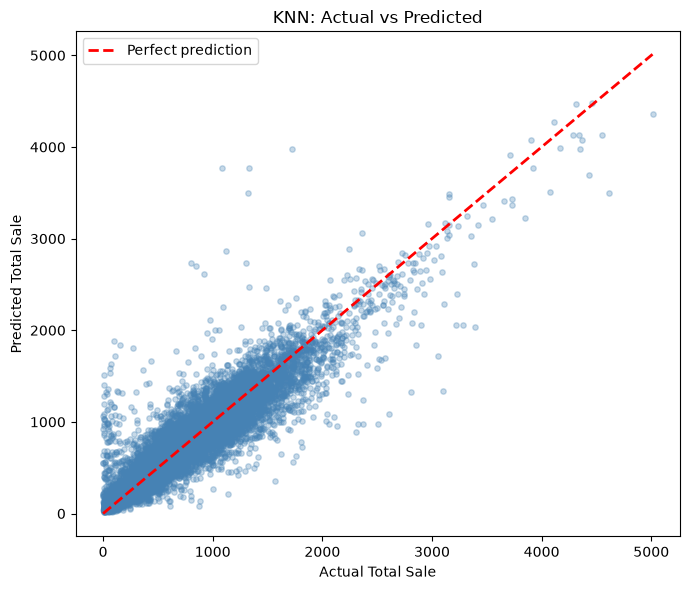

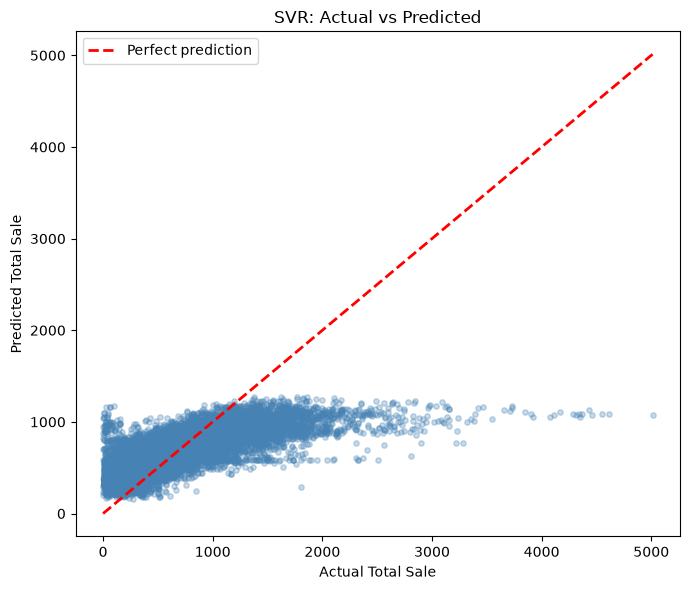

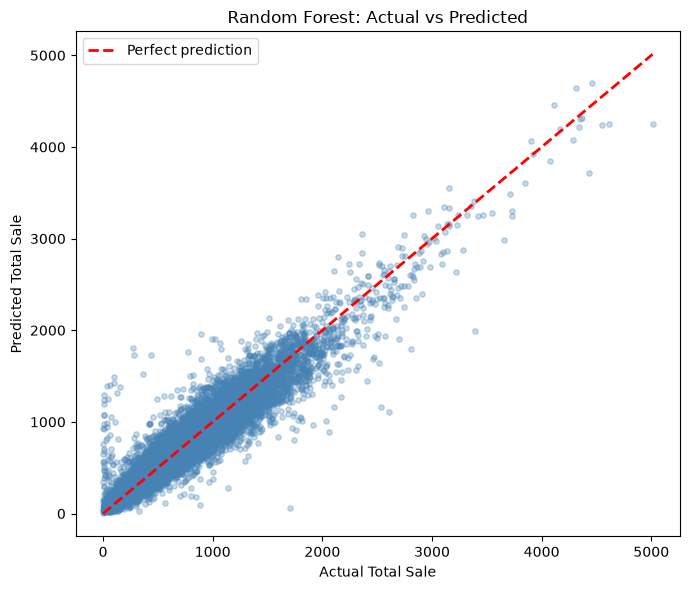

In [33]:
def plot_actual_vs_predicted(y_true, y_pred, model_name):
    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.3, s=15, color="steelblue")

    # Perfect prediction line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        "r--",
        linewidth=2,
        label="Perfect prediction",
    )

    plt.xlabel("Actual Total Sale")
    plt.ylabel("Predicted Total Sale")
    plt.title(f"{model_name}: Actual vs Predicted")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_actual_vs_predicted(y_test, knn_preds, "KNN")
plot_actual_vs_predicted(y_test, svr_preds, "SVR")
plot_actual_vs_predicted(y_test, rf_preds, "Random Forest")


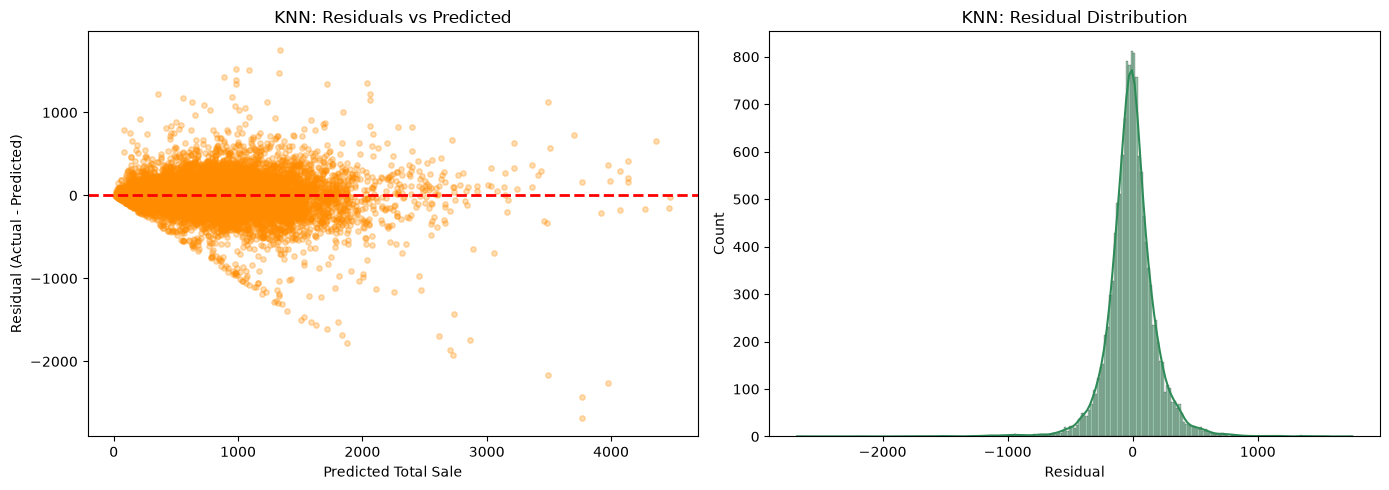

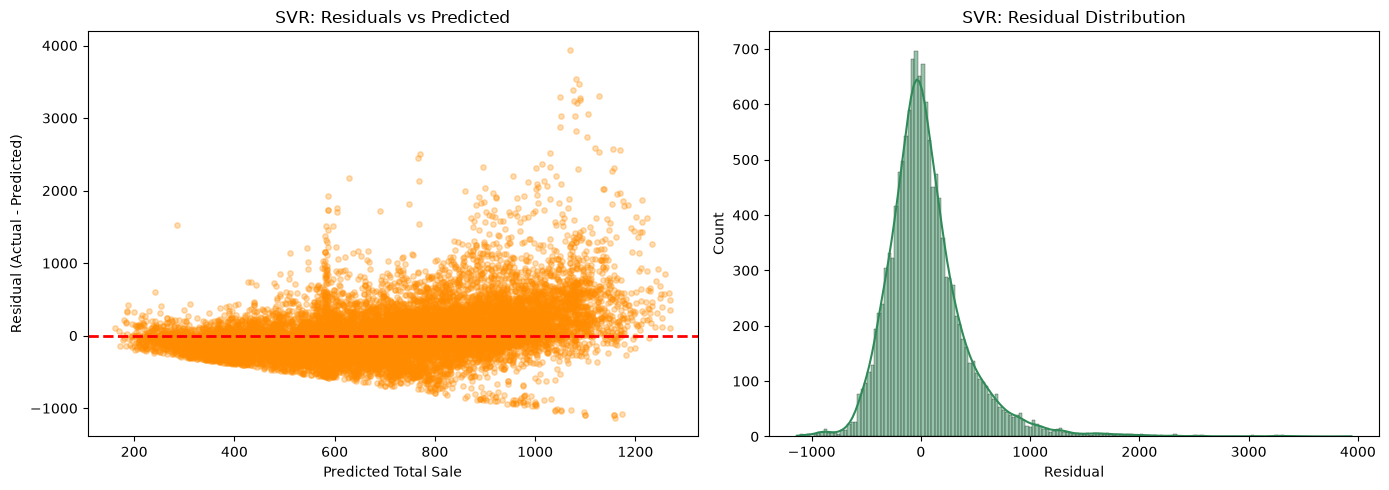

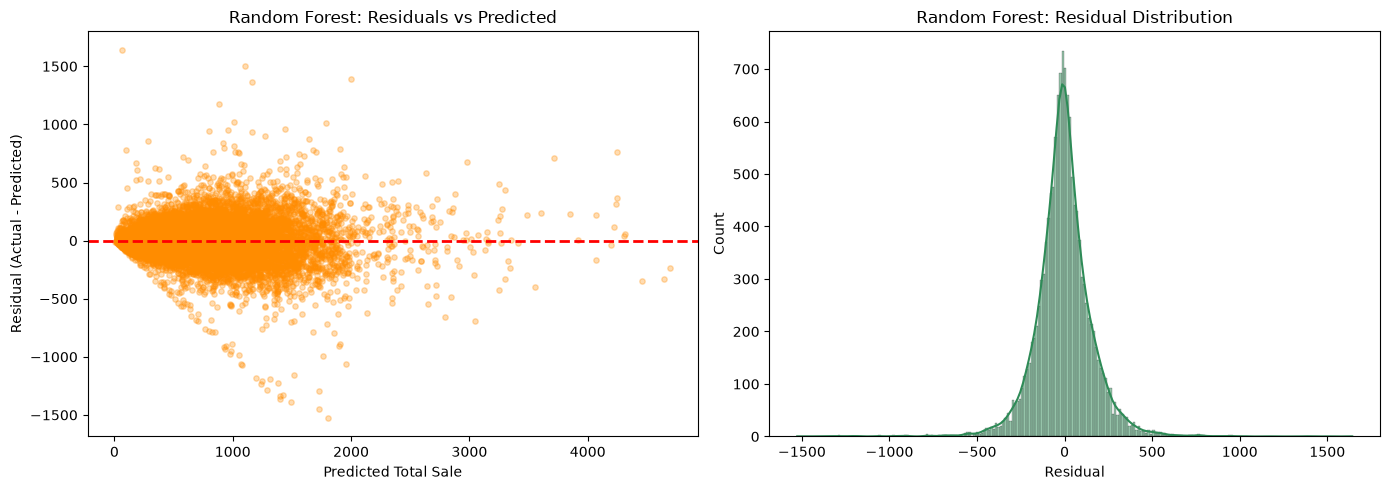

In [34]:
def plot_residuals(y_true, y_pred, model_name):
    residuals = y_true - y_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Residuals vs predicted
    axes[0].scatter(y_pred, residuals, alpha=0.3, s=15, color="darkorange")
    axes[0].axhline(y=0, color="red", linestyle="--", linewidth=2)
    axes[0].set_xlabel("Predicted Total Sale")
    axes[0].set_ylabel("Residual (Actual - Predicted)")
    axes[0].set_title(f"{model_name}: Residuals vs Predicted")

    # Residual distribution
    sns.histplot(residuals, kde=True, ax=axes[1], color="seagreen")
    axes[1].set_xlabel("Residual")
    axes[1].set_title(f"{model_name}: Residual Distribution")

    plt.tight_layout()
    plt.show()


plot_residuals(y_test, knn_preds, "KNN")
plot_residuals(y_test, svr_preds, "SVR")
plot_residuals(y_test, rf_preds, "Random Forest")


C:\Users\farma\AppData\Local\Temp\ipykernel_13972\1266738859.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[0], palette="Blues_d")
C:\Users\farma\AppData\Local\Temp\ipykernel_13972\1266738859.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[1], palette="Oranges_d")
C:\Users\farma\AppData\Local\Temp\ipykernel_13972\1266738859.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2", ax=axes[2], palette="Greens_d"

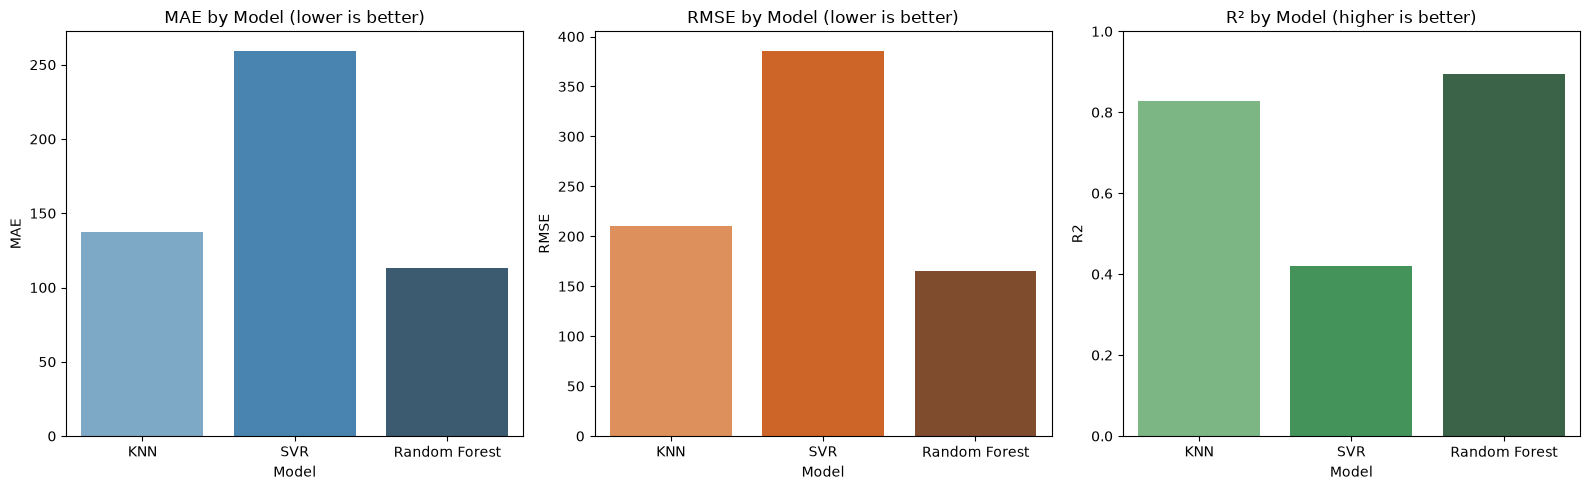

In [35]:
results_df = pd.DataFrame(
    [
        {
            "Model": "KNN",
            "MAE": mean_absolute_error(y_test, knn_preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, knn_preds)),
            "R2": r2_score(y_test, knn_preds),
        },
        {
            "Model": "SVR",
            "MAE": mean_absolute_error(y_test, svr_preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, svr_preds)),
            "R2": r2_score(y_test, svr_preds),
        },
        {"Model": "Random Forest", "MAE": rf_mae, "RMSE": rf_rmse, "R2": rf_r2},
    ]
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.barplot(data=results_df, x="Model", y="MAE", ax=axes[0], palette="Blues_d")
axes[0].set_title("MAE by Model (lower is better)")

sns.barplot(data=results_df, x="Model", y="RMSE", ax=axes[1], palette="Oranges_d")
axes[1].set_title("RMSE by Model (lower is better)")

sns.barplot(data=results_df, x="Model", y="R2", ax=axes[2], palette="Greens_d")
axes[2].set_title("R² by Model (higher is better)")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()


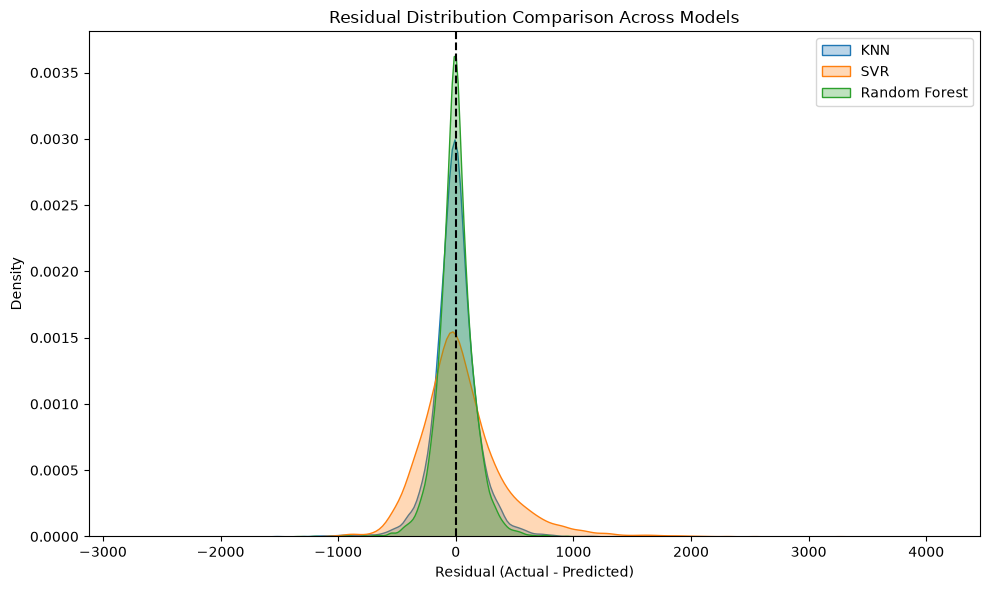

In [36]:
plt.figure(figsize=(10, 6))
sns.kdeplot(y_test - knn_preds, label="KNN", fill=True, alpha=0.3)
sns.kdeplot(y_test - svr_preds, label="SVR", fill=True, alpha=0.3)
sns.kdeplot(y_test - rf_preds, label="Random Forest", fill=True, alpha=0.3)
plt.axvline(x=0, color="black", linestyle="--")
plt.xlabel("Residual (Actual - Predicted)")
plt.title("Residual Distribution Comparison Across Models")
plt.legend()
plt.tight_layout()
plt.show()


High correlation pairs (>0.95):
working <-> unemployment_rate: 1.000
unemployed <-> unemployment_rate: 1.000
unemployed <-> working: 1.000
non-white <-> white: 1.000


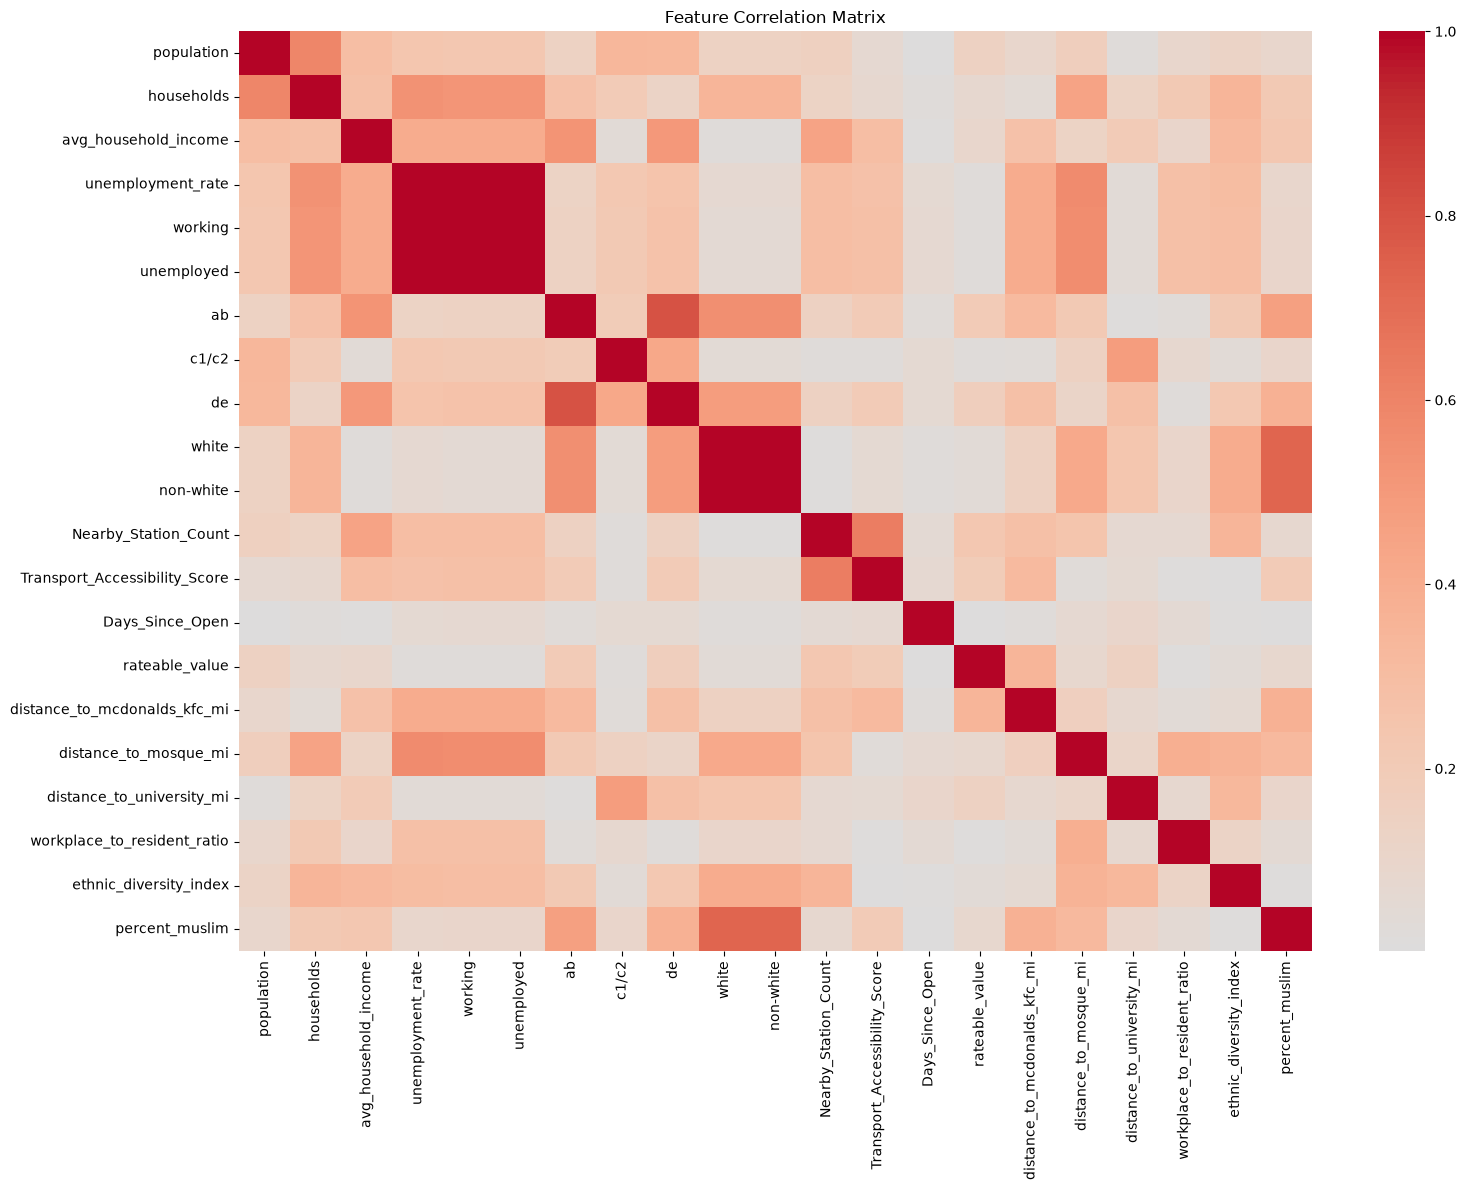

Dropped due to multicollinearity: {'white', 'unemployment_rate', 'working'}


In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Correlation matrix on numeric features only
corr_matrix = X[num_cols].corr().abs()

# Find pairs with correlation > 0.95
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if upper_tri.loc[row, col] is not None and upper_tri.loc[row, col] > 0.95
]

print("High correlation pairs (>0.95):")
for col1, col2, corr_val in high_corr_pairs:
    print(f"{col1} <-> {col2}: {corr_val:.3f}")

# Visualize full matrix
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Drop one column from each high-correlation pair
cols_to_drop = set(col2 for col1, col2, _ in high_corr_pairs)
num_cols = [c for c in num_cols if c not in cols_to_drop]
print("Dropped due to multicollinearity:", cols_to_drop)


In [38]:
from scipy.stats import skew, kurtosis

skew_kurt_df = pd.DataFrame(
    {
        "feature": num_cols,
        "skewness": [skew(X[col].dropna()) for col in num_cols],
        "kurtosis": [kurtosis(X[col].dropna()) for col in num_cols],
    }
).sort_values("skewness", key=abs, ascending=False)

print(skew_kurt_df)

# Rule of thumb: |skew| > 1 = highly skewed -> log transform
# 0.5-1 = moderate -> consider robust scaling
# <0.5 = roughly symmetric -> standard scaling is fine
highly_skewed = skew_kurt_df[skew_kurt_df["skewness"].abs() > 1]["feature"].tolist()
print("Highly skewed features (apply log transform):", highly_skewed)


                          feature   skewness    kurtosis
15    workplace_to_resident_ratio  29.458445  962.000385
13          distance_to_mosque_mi   8.236656  105.430667
14      distance_to_university_mi   4.317644   21.586865
3                      unemployed   3.963674   30.329411
1                      households   3.806850   17.313823
11                 rateable_value   3.034701   10.505978
9   Transport_Accessibility_Score  -2.051125    2.879809
0                      population   1.952747    4.996812
17                 percent_muslim   1.817106    2.441983
12   distance_to_mcdonalds_kfc_mi   1.108265    1.446435
16         ethnic_diversity_index  -0.818593   -0.426028
4                              ab   0.774841    0.067499
6                              de   0.682272    0.820140
2            avg_household_income   0.680826    0.021833
10                Days_Since_Open   0.524833   -0.707928
5                           c1/c2  -0.471163    0.163593
8            Nearby_Station_Cou

In [39]:
from sklearn.preprocessing import RobustScaler

# Apply log1p to highly skewed features (handles zeros safely, unlike log)
for col in highly_skewed:
    X[col] = np.log1p(X[col] - X[col].min() + 1)  # shift if negative values exist

# Update preprocessor: use RobustScaler for moderately skewed, StandardScaler for the rest
moderately_skewed = skew_kurt_df[
    (skew_kurt_df["skewness"].abs() > 0.5) & (skew_kurt_df["skewness"].abs() <= 1)
]["feature"].tolist()
normal_cols = [
    c for c in num_cols if c not in highly_skewed and c not in moderately_skewed
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num_standard", StandardScaler(), normal_cols),
        ("num_robust", RobustScaler(), moderately_skewed + highly_skewed),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("bin", "passthrough", binary_flags),
    ]
)


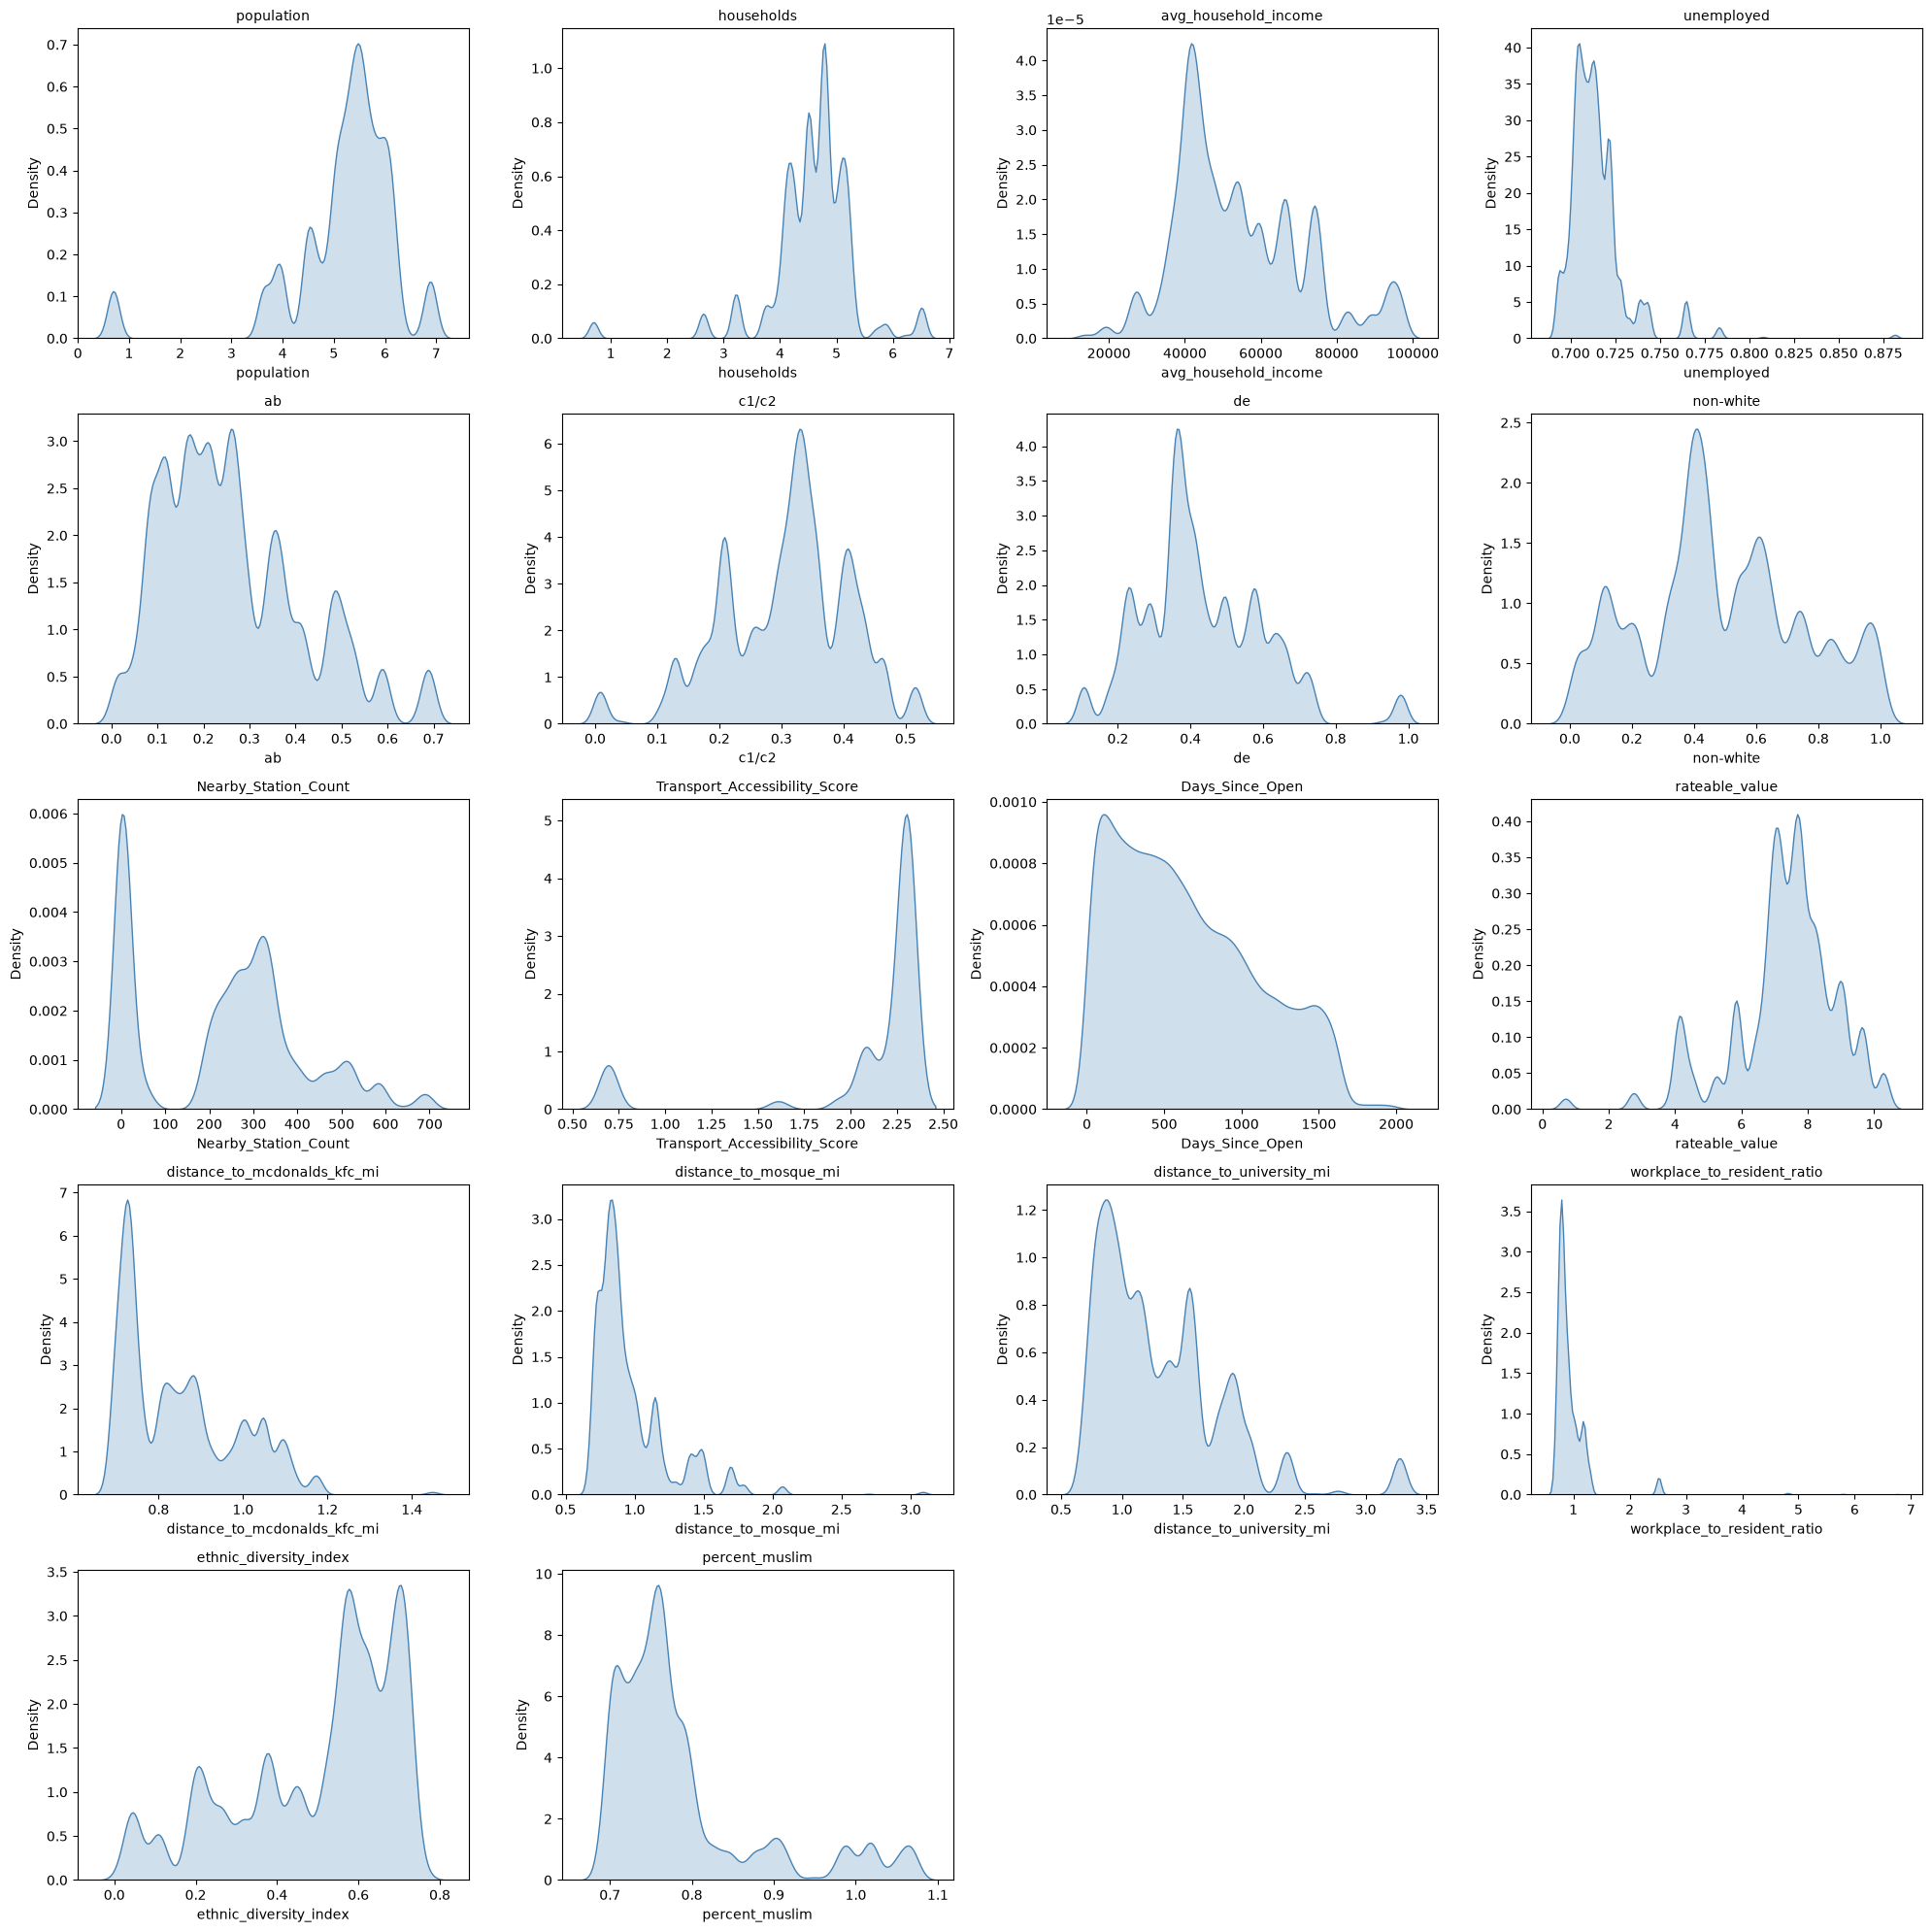

In [40]:
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(X[col].dropna(), fill=True, ax=axes[i], color="steelblue")
    axes[i].set_title(col, fontsize=10)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import optuna 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


,Day_of_Week,Branch Name,Total Sale,population,households,avg_household_income,unemployment_rate,working,unemployed,ab,...,rateable_value,distance_to_nearest_station_mi,distance_to_mcdonalds_kfc_mi,distance_to_mosque_mi,distance_to_university_mi,workplace_to_resident_ratio,ethnic_diversity_index,Month,Year,outercode_freq
0,Saturday,galos peri peri hamilton,347.53,686,548,13716.9812,0.43,0.5803,0.4197,0.1928,...,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.016,2,2025,0.002216
1,Sunday,galos peri peri hamilton,119.68,686,548,13716.9812,0.43,0.5803,0.4197,0.1928,...,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.016,2,2025,0.002216
2,Monday,galos peri peri hamilton,136.20,686,548,13716.9812,0.43,0.5803,0.4197,0.1928,...,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.016,2,2025,0.002216
3,Tuesday,galos peri peri hamilton,92.67,686,548,13716.9812,0.43,0.5803,0.4197,0.1928,...,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.016,2,2025,0.002216
4,Wednesday,galos peri peri hamilton,124.94,686,548,13716.9812,0.43,0.5803,0.4197,0.1928,...,1365.0,0.241441,2.277612,19.979787,14.023843,120.827,0.016,2,2025,0.002216


In [ ]:
print(df.isnull().sum())


In [44]:
def knn_objective(trial):
    n_neighbors = trial.suggest_int("n_neighbors", 2, 30)
    weights = trial.suggest_categorical("weights", ["uniform", "distance"])
    p = trial.suggest_int("p", 1, 2)  # 1=manhattan, 2=euclidean

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "regressor",
                KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, p=p),
            ),
        ]
    )

    score = cross_val_score(
        pipeline, X_train, y_train, cv=3, scoring="r2", n_jobs=-1
    ).mean()
    return score


knn_study = optuna.create_study(direction="maximize")
knn_study.optimize(knn_objective, n_trials=30)

print("Best KNN params:", knn_study.best_params)
print("Best KNN CV R2:", knn_study.best_value)


[W 2026-08-01 00:13:20,916] Trial 13 failed with parameters: {'n_neighbors': 14, 'weights': 'distance', 'p': 1} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\farma\AppData\Local\Temp\ipykernel_3104\3799776013.py", line 16, in knn_objective
    score = cross_val_score(
            ~~~~~~~~~~~~~~~^
        pipeline, X_train, y_train, cv=3, scoring="r2", n_jobs=-1
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ).mean()
    ^
  File "C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
  File "C:\Users\farma\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 650, in cross_val_score
    cv_results = cross_validate(
  

KeyboardInterrupt: 

In [ ]:
def svr_objective(trial):
    C = trial.suggest_float("C", 0.1, 500, log=True)
    epsilon = trial.suggest_float("epsilon", 0.01, 2.0, log=True)
    gamma = trial.suggest_categorical("gamma", ["scale", "auto"])
    kernel = trial.suggest_categorical("kernel", ["rbf", "linear"])

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", SVR(C=C, epsilon=epsilon, gamma=gamma, kernel=kernel)),
        ]
    )
    score = cross_val_score(
        pipeline, X_train, y_train, cv=3, scoring="r2", n_jobs=-1
    ).mean()
    return score


svr_study = optuna.create_study(direction="maximize")
svr_study.optimize(svr_objective, n_trials=30)

print("Best SVR params:", svr_study.best_params)
print("Best SVR CV R2:", svr_study.best_value)


## 4. Exploratory Data Analysis (EDA)

### 4.1 Density Plots — Distribution of Every Feature
Identify skewed features visually before transforming.

## 5. Skewness & Kurtosis Analysis
### 5.1 Compute Skewness and Kurtosis per Feature
### 5.2 Apply Transformations (log, StandardScaler, RobustScaler)

## 6. Multicollinearity Check
### 6.1 Correlation Matrix / VIF
### 6.2 Remove or Transform Features with Correlation > 0.95

## 7. Feature Engineering (Final Feature Set)

## 8. Train-Test Split

## 9. Baseline Model Training
Train all regressor models covered in scikit-learn using default/manual parameters.

## 10. Baseline Model Evaluation
### 10.1 RMSE, MSE, MAE for Each Model
### 10.2 Comparison Table

## 11. Hyperparameter Optimization (Optuna)
### 11.1 Define Search Space per Model
### 11.2 Run Optuna Study
### 11.3 Retrain Models with Optimized Parameters